# Building Custom Policies with JaxPlan

This advanced notebook illustrates how a custom policy implementation can be designed with JaxPlan.

First install and import the required packages:

In [1]:
%pip install --quiet --upgrade pip
%pip install --quiet pyRDDLGym rddlrepository pyRDDLGym-jax

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Import the required packages:

In [2]:
import os
from IPython.display import Image
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import jax
import jax.numpy as jnp

import pyRDDLGym
from pyRDDLGym.core.visualizer.movie import MovieGenerator
from pyRDDLGym_jax.core.planner import JaxBackpropPlanner, JaxOfflineController, JaxPlan, get_action_info

We will optimize the continuous reservoir control problem as an example.

In [3]:
env = pyRDDLGym.make('Reservoir_Continuous', '0', vectorized=True)

We will now build a custom piecewise linear policy in JaxPlan. That is, we will define a factored policy per reservoir that is piecewise linear in the rlevel(?r):

`release(?r) = if (rlevel(?r) >= T) then V1(?r) else V2(?r)`

During training, we will relax this policy such that it supports backpropagation to update the parameters (T, V1, V2):

`release(?r) = sigmoid(w * (rlevel(?r) - T)) * (V1 - V2) + V2`

where w is a hyperparameter.

In [4]:
class PWLinearPolicy(JaxPlan):
    history_dependent = False

    def __init__(self, action_sigmoid=10.0):
        self.action_sigmoid = action_sigmoid

    def compile(self, compiled, test_compiled, _bounds, horizon, preprocessor=None) -> None:

        # compute bounds on action fluents and project to valid range
        shapes, bounds, _, _ = get_action_info(compiled, _bounds, horizon)
        self.bounds = bounds
        def project_fn(params, hyperparams):
            new_params = {name: jnp.clip(value, *bounds['release']) for name, value in params.items()}
            return new_params, True
        self.projection = project_fn

        # initialize T, V1, and V2 to valid action bounds and sigmoid weight for soft action
        def init_fn(key, fls):
            hyperparams = {'sigmoid': self.action_sigmoid}
            keys = jax.random.split(key, num=3)
            T = 0.01 * jax.random.normal(keys[0], shapes['release'][1:])
            V1 = 0.01 * jax.random.normal(keys[1], shapes['release'][1:])
            V2 = 0.01 * jax.random.normal(keys[2], shapes['release'][1:])
            params, _ = project_fn({'T': T, 'V1': V1, 'V2': V2}, hyperparams)
            return params, hyperparams
        self.initializer = init_fn

        # apply soft action with gradient propagation
        def apply_train_fn(key, params, hyperparams, step, fls, fls_hist, nfls):
            cond = jax.nn.sigmoid(hyperparams['sigmoid'] * (fls['rlevel'] - params['T']))
            actions = {'release': cond * params['V1'] + (1 - cond) * params['V2']}
            return actions        
        self.train_policy = apply_train_fn

        # apply hard action for evaluation
        def apply_test_fn(key, params, hyperparams, step, fls, fls_hist, nfls):
            cond = jnp.greater_equal(fls['rlevel'], params['T'])
            actions = {'release': jnp.where(cond, params['V1'], params['V2'])}
            return actions 
        self.test_policy = apply_test_fn

    def guess_next_epoch(self, params):
        return params

We can now initialize and train this policy as usual:

In [5]:
planner = JaxBackpropPlanner(rddl=env.model, plan=PWLinearPolicy())
agent = JaxOfflineController(planner, print_summary=False, train_seconds=20)
agent.evaluate(env, episodes=10)

[INFO] Compiler will cast pvars {'CONNECTED_TO_SEA', 'RES_CONNECT'} to float.
[INFO] Bounds of action-fluent <release> set to (array([0., 0., 0.], dtype=float32), array([100., 100., 100.], dtype=float32)).


 740 it |    -460.32190 train |    -704.40637 test |     -80.81693 [68 it] pgpe |     -56.26297 best | 5 status: 100%|██████████| 00:19 , 37.02it/s


{'mean': np.float64(-55.70986071633661),
 'median': np.float64(0.0),
 'min': np.float64(-557.0986071633661),
 'max': np.float64(0.0),
 'std': np.float64(167.12958214900982)}

This policy performs near optimally. Let's print the T, V1 and V2 parameters:

In [6]:
print(agent.params)

{'T': Array([0.40481523, 2.8260245 , 0.54139143], dtype=float32), 'V1': Array([1.733093 , 1.760544 , 5.2678385], dtype=float32), 'V2': Array([1.6135397 , 0.3262439 , 0.04709663], dtype=float32)}


Finally, let's visualize the policy:

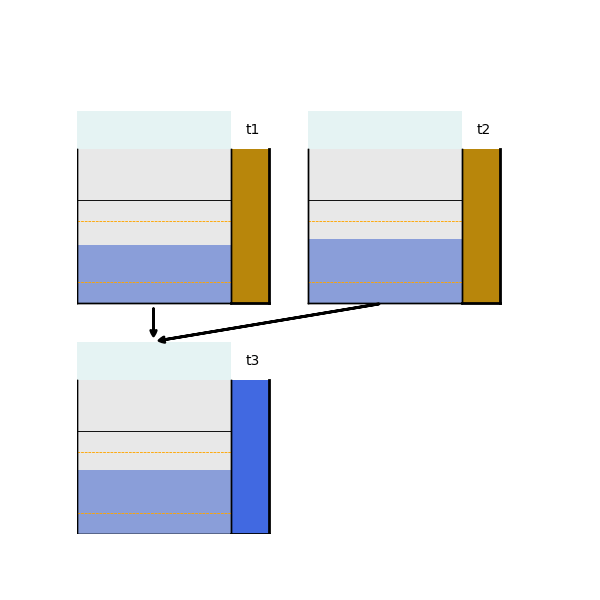

In [7]:
if not os.path.exists('frames'):
    os.makedirs('frames')
recorder = MovieGenerator("frames", "reservoir", max_frames=env.horizon)
env.set_visualizer(viz=None, movie_gen=recorder)
agent.evaluate(env, episodes=1, render=True)
env.close()
Image(filename='frames/reservoir_0.gif') 